# Delphi — Mental Health Trajectory Generation
### Paper: *Learning the Natural History of Human Disease with Generative Transformers*



In [15]:

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU found. Go to Runtime → Change runtime type → T4 GPU')

Using device: cuda
GPU: Tesla T4


In [16]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import defaultdict
import torch.nn.functional as F
warnings.filterwarnings('ignore')

from model import DelphiConfig, Delphi
from utils import get_batch, get_p2i

os.makedirs('delphi_plots', exist_ok=True)
print('Imports done.')

Imports done.


In [17]:

print('Loading model...')
checkpoint = torch.load('ckpt.pt', map_location=device)
conf  = DelphiConfig(**checkpoint['model_args'])
model = Delphi(conf)
model.load_state_dict(checkpoint['model'])
model.eval()
model = model.to(device)
print(f'Model loaded on {device}')
print(f'vocab_size={conf.vocab_size}, n_layer={conf.n_layer}, n_head={conf.n_head}')

Loading model...
number of parameters: 2.24M
Model loaded on cuda
vocab_size=1270, n_layer=12, n_head=12


In [18]:

delphi_labels = pd.read_csv('delphi_labels_chapters_colours_icd.csv')

MENTAL_COL = 'ICD-10 Chapter (short)'
MH_CHAPTER = 'V. Mental Disorders'
mh_mask    = delphi_labels[MENTAL_COL] == MH_CHAPTER
mh_tokens  = set(delphi_labels.index[mh_mask].tolist())
print(f'Mental health tokens: {len(mh_tokens)}')
print('Example MH diseases:')
print(delphi_labels[mh_mask][['name']].head(10).to_string())

def token_label(tok):
    tok = int(tok)
    if tok < len(delphi_labels):
        row   = delphi_labels.iloc[tok]
        name  = row.get('name', str(tok))
        color = row.get('color', '#888888')
        is_mh = (row.get(MENTAL_COL, '') == MH_CHAPTER)
    else:
        name, color, is_mh = str(tok), '#888888', False
    return name, color, is_mh

Mental health tokens: 77
Example MH diseases:
                                                                                       name
276                                                     F00 Dementia in alzheimer's disease
277                                                                   F01 Vascular dementia
278                                     F02 Dementia in other diseases classified elsewhere
279                                                                F03 Unspecified dementia
280  F04 Organic amnesic syndrome, not induced by alcohol and other psychoactive substances
281                  F05 Delirium, not induced by alcohol and other psychoactive substances
282  F06 Other mental disorders due to brain damage and dysfunction and to physical disease
283  F07 Personality and behavioural disorders due to brain disease, damage and dysfunction
284                                  F09 Unspecified organic or symptomatic mental disorder
285                              F

In [19]:
# ── Cell 5: Load & Prepare Data ───────────────────────────────────────────
print('Loading patient data...')
train = np.fromfile('train.bin', dtype=np.uint32).reshape(-1, 3)
val   = np.fromfile('val.bin',   dtype=np.uint32).reshape(-1, 3)
train_p2i = get_p2i(train)
val_p2i   = get_p2i(val)

d = get_batch(range(0, val_p2i.shape[0]-1, 1), val, val_p2i,
              select='left', block_size=63,
              device=device, padding='random')

age = 60
n_samples = len(d[0])

# Keep patients with history both before AND after age 60
w = np.where(
    (d[1].cpu().numpy() <= age * 365.25).any(1) *
    (d[3].cpu().numpy() >= age * 365.25).any(1)
)
u = np.unique(w[0])
print(f'Eligible patients: {len(u)}')

# Build input tensors — history truncated at age 60
d0 = d[0][u].clone().detach()
d1 = d[1][u].clone().detach()
d0[d1 > age * 365.25] = 0
d1[d1 > age * 365.25] = -10000.0

# Append age-60 marker token
d0 = F.pad(d0, (0, 1), 'constant', 1)
d1 = F.pad(d1, (0, 1), 'constant', age * 365.25)

# Sort chronologically
o  = d1.argsort(1)
d0 = d0.gather(1, o)
d1 = d1.gather(1, o)
print(f'Input shape: {d0.shape}')

Loading patient data...
Eligible patients: 7121
Input shape: torch.Size([7121, 64])


In [20]:
# ── Cell 6: Generate Trajectories ────────────────────────────────────────


N_PATIENTS  = 500      # <-- increase this if time allows (try 500)
MAX_TOKENS  = 50
trajectories = []

# Use every 3rd patient for variety
candidate_idx = list(range(0, min(len(d0), N_PATIENTS * 5), 3))

print(f'Generating trajectories for up to {N_PATIENTS} patients...')

for idx in candidate_idx:
    if len(trajectories) >= N_PATIENTS:
        break
    try:
        with torch.no_grad():
            mm = model.generate(
                d0[idx:idx+1].to(device),
                d1[idx:idx+1].to(device),
                max_age=80 * 365.25,
                no_repeat=True,
                max_new_tokens=MAX_TOKENS,
                termination_tokens=[1269],
            )

        if len(mm[0]) == 0:
            del mm; gc.collect(); continue

        evs  = mm[0][0].cpu().numpy()
        tims = mm[1][0].cpu().numpy()
        del mm; gc.collect()

        mask = (evs > 1) & (tims > 0)
        evs  = evs[mask]
        tims = tims[mask]

        if len(evs) == 0:
            continue

        ages = tims / 365.25
        trajectories.append({
            'idx':    idx,
            'events': evs.tolist(),
            'ages':   ages.tolist(),
        })

        if len(trajectories) % 20 == 0:
            print(f'  {len(trajectories)}/{N_PATIENTS} done...')

    except Exception as e:
        continue

print(f'\nDone! Generated {len(trajectories)} trajectories.')

# Flat lists for analysis
all_events = [(age_v, int(tok), pid)
              for pid, t in enumerate(trajectories)
              for age_v, tok in zip(t['ages'], t['events'])]
all_ages   = np.array([x[0] for x in all_events])
all_tokens = np.array([x[1] for x in all_events])
is_mh      = np.array([int(tok) in mh_tokens for tok in all_tokens])
mh_ages    = all_ages[is_mh]
mh_tokens_ = all_tokens[is_mh]

print(f'Total events: {len(all_events)}')
print(f'Mental health events: {is_mh.sum()} ({100*is_mh.mean():.1f}%)')

Generating trajectories for up to 500 patients...
  20/500 done...
  40/500 done...
  60/500 done...
  80/500 done...
  100/500 done...
  120/500 done...
  140/500 done...
  160/500 done...
  180/500 done...
  200/500 done...
  220/500 done...
  240/500 done...
  260/500 done...
  280/500 done...
  300/500 done...
  320/500 done...
  340/500 done...
  360/500 done...
  380/500 done...
  400/500 done...
  420/500 done...
  440/500 done...
  460/500 done...
  480/500 done...
  500/500 done...

Done! Generated 500 trajectories.
Total events: 11175
Mental health events: 386 (3.5%)


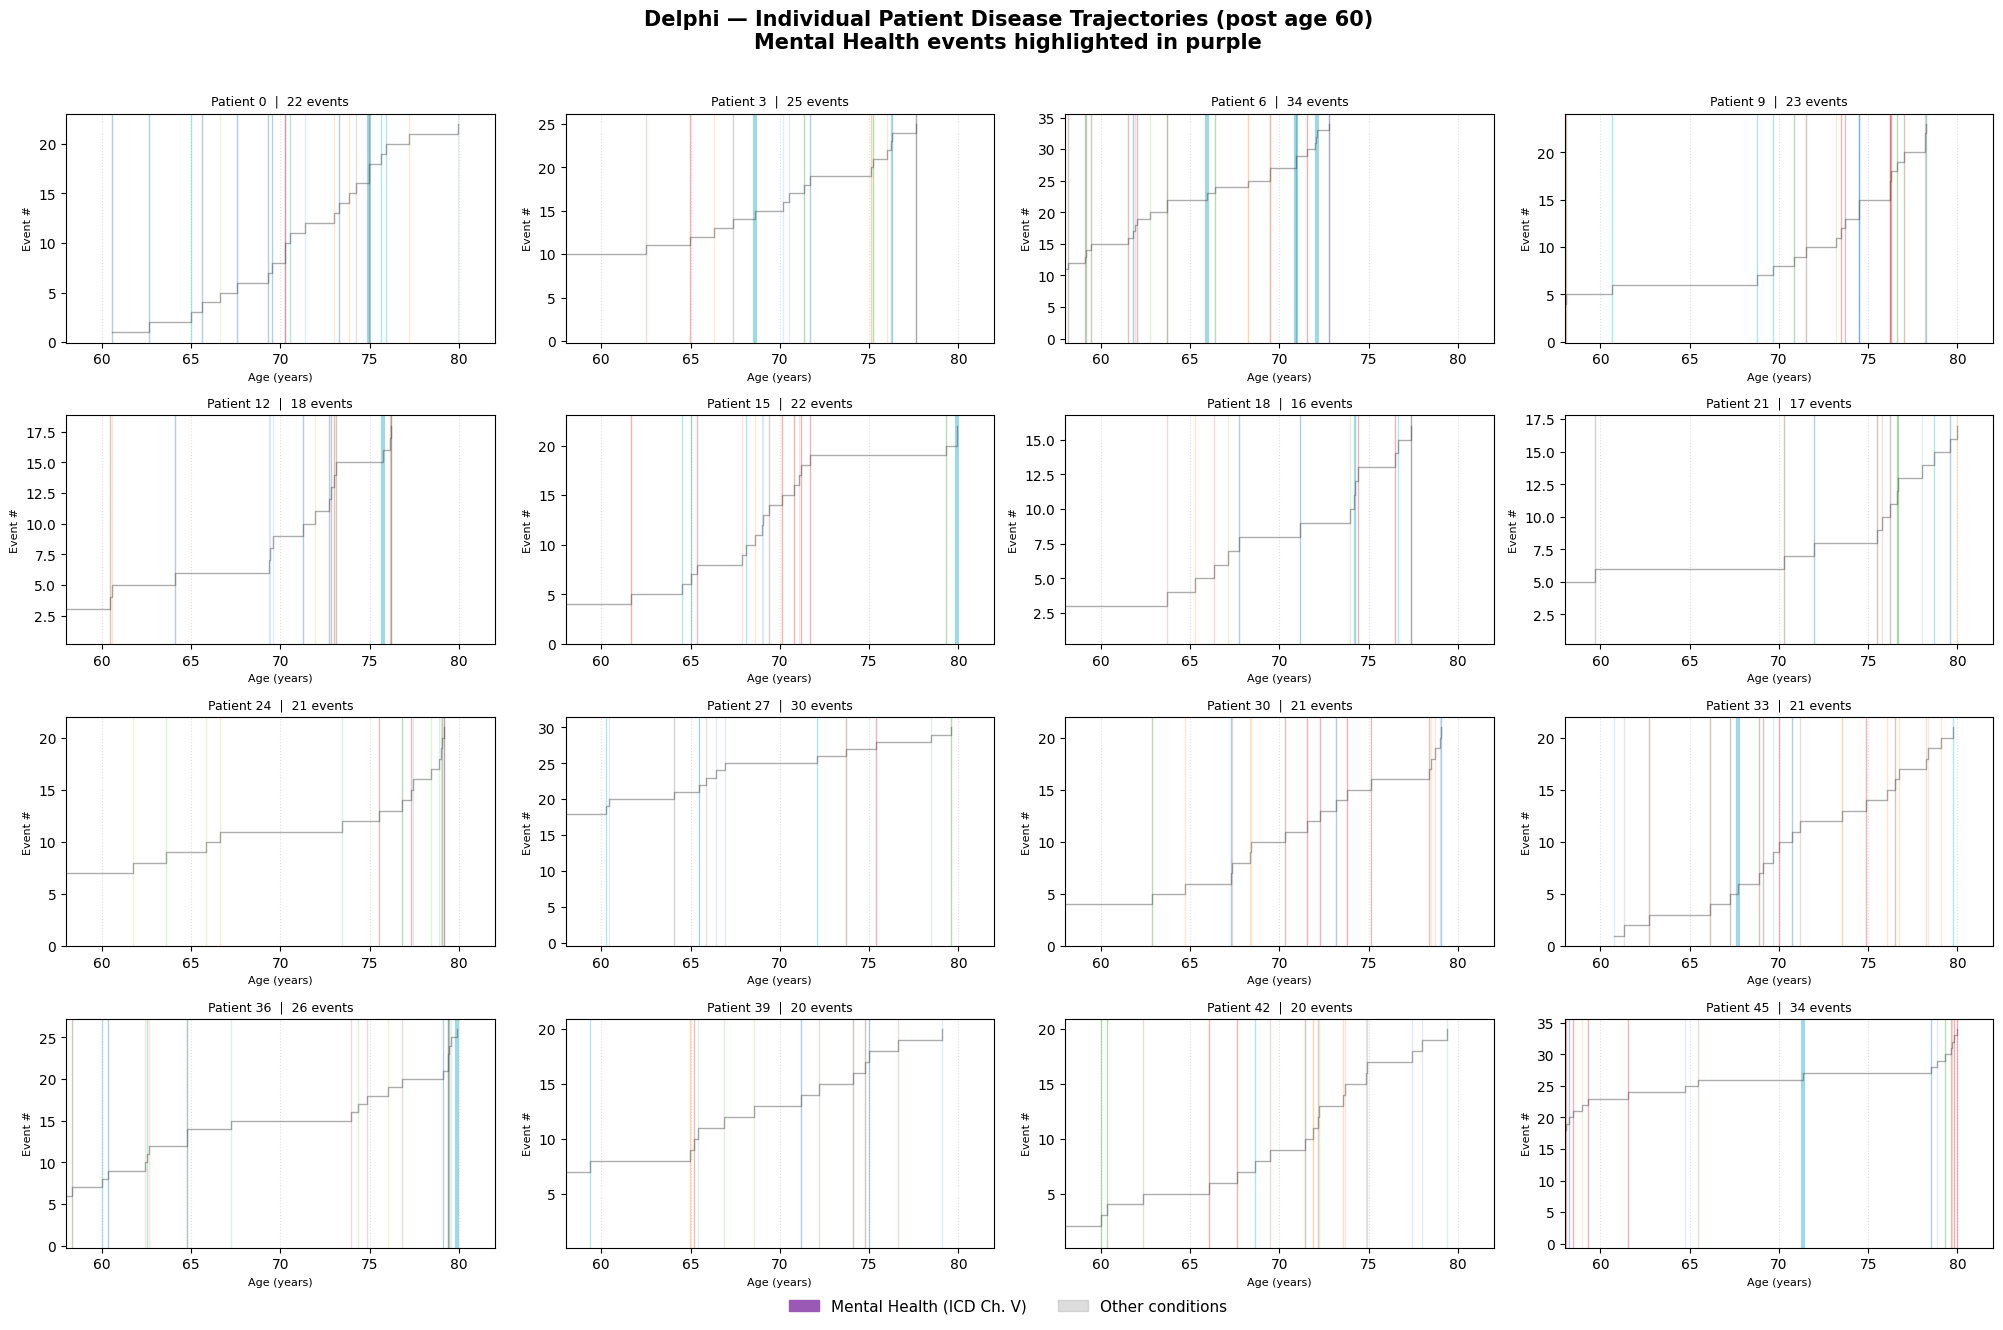

Saved plot1


In [21]:
# ── Cell 7: PLOT 1 — Individual Trajectories ──────────────────────────────
N_SHOW = 16
cols, rows = 4, 4

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3.2))
fig.suptitle('Delphi — Individual Patient Disease Trajectories (post age 60)\nMental Health events highlighted in purple',
             fontsize=15, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
for ai, traj in enumerate(trajectories[:N_SHOW]):
    ax     = axes_flat[ai]
    ages_t = np.array(traj['ages'])
    evts_t = np.array(traj['events'])
    order  = np.argsort(ages_t)
    ages_t = ages_t[order]
    evts_t = evts_t[order]

    for a, tok in zip(ages_t, evts_t):
        name, col, is_mh_flag = token_label(tok)
        ax.axvline(a, color=col,
                   lw=3.0 if is_mh_flag else 1.0,
                   alpha=1.0 if is_mh_flag else 0.35)

    ax.step(ages_t, range(1, len(ages_t)+1), where='post',
            color='#333333', lw=1.0, alpha=0.4)
    ax.set_xlim(58, 82)
    ax.set_xlabel('Age (years)', fontsize=8)
    ax.set_ylabel('Event #', fontsize=8)
    ax.set_title(f"Patient {traj['idx']}  |  {len(ages_t)} events", fontsize=9)
    ax.grid(True, axis='x', linestyle=':', alpha=0.4)

mh_patch  = mpatches.Patch(color='#9b59b6', label='Mental Health (ICD Ch. V)')
oth_patch = mpatches.Patch(color='#aaaaaa', label='Other conditions', alpha=0.4)
fig.legend(handles=[mh_patch, oth_patch], loc='lower center',
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig('delphi_plots/plot1_individual_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot1')

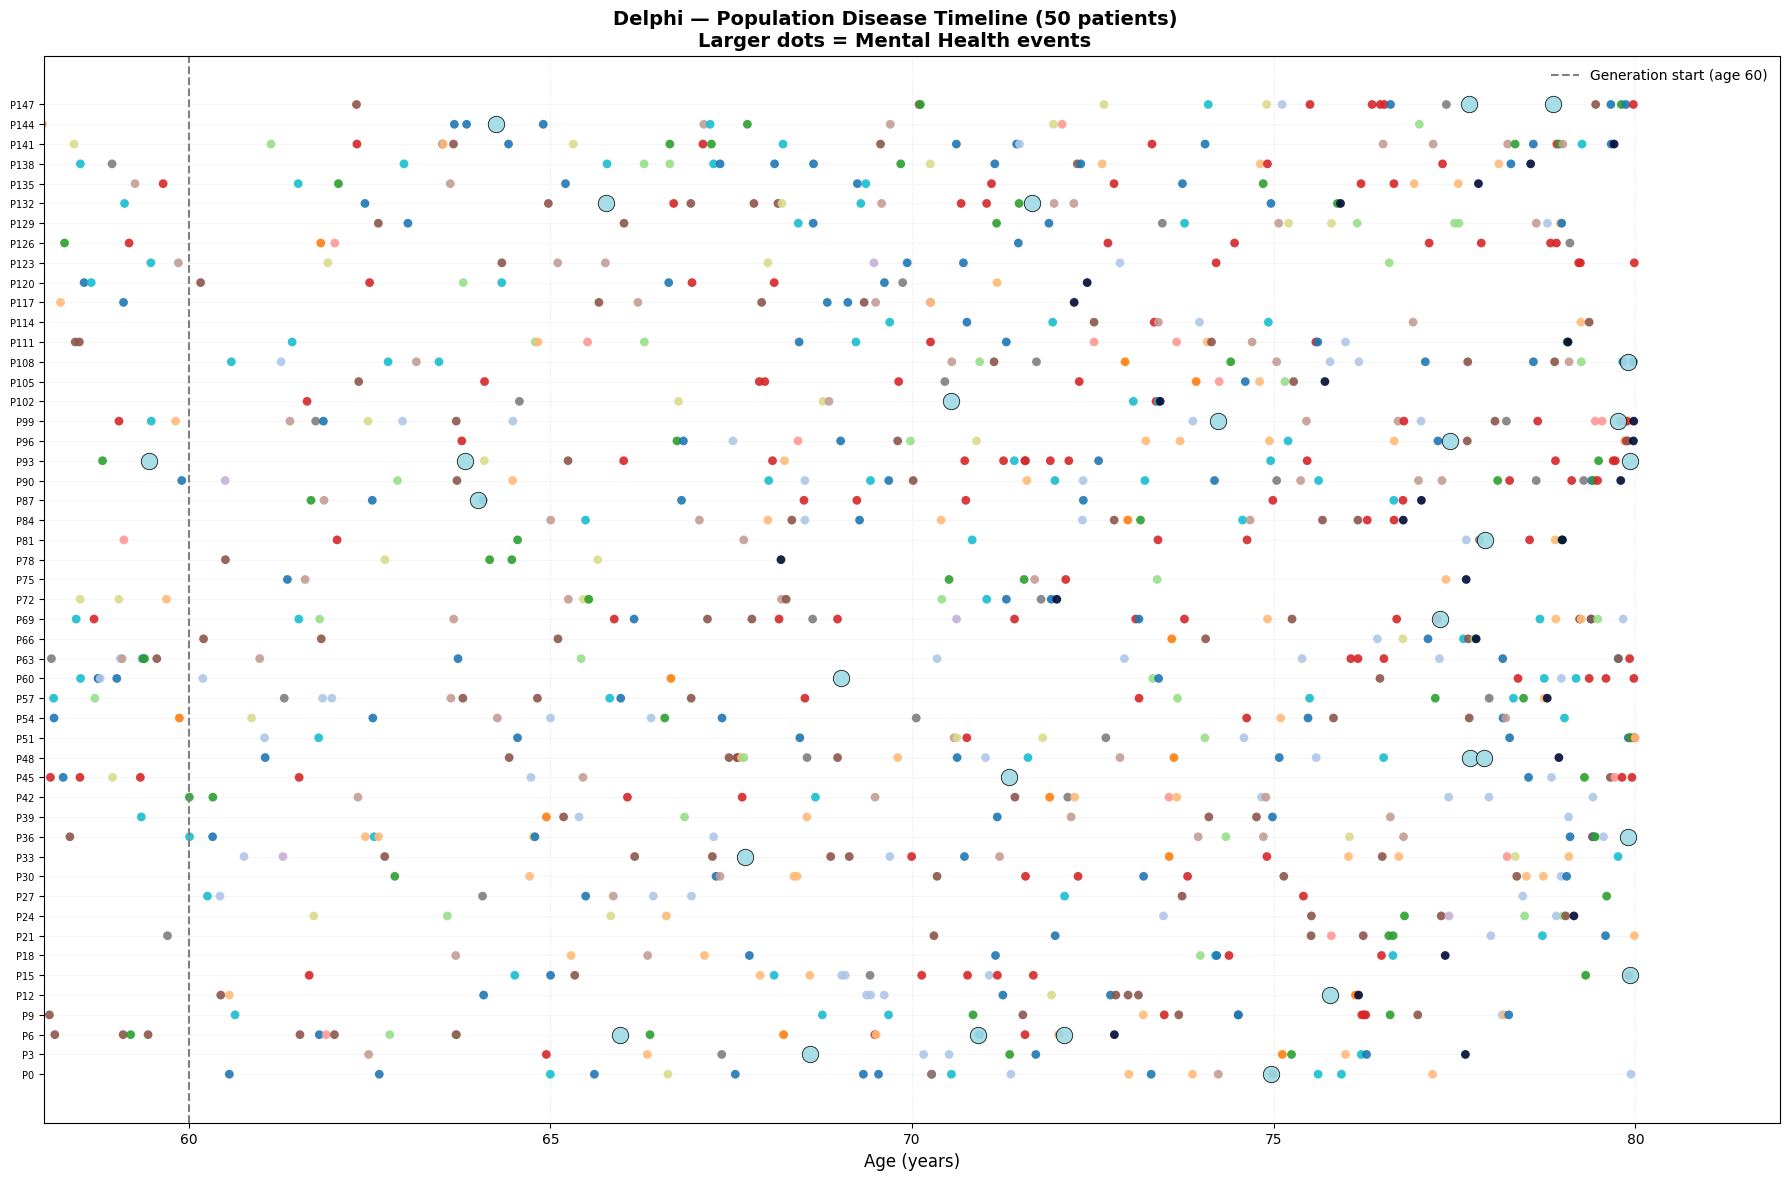

Saved plot2


In [22]:
# ── Cell 8: PLOT 2 — Population Timeline ─────────────────────────────────
N_SHOW2 = min(50, len(trajectories))

fig, ax = plt.subplots(figsize=(18, 12))
fig.suptitle(f'Delphi — Population Disease Timeline ({N_SHOW2} patients)\nLarger dots = Mental Health events',
             fontsize=14, fontweight='bold')

for yi, traj in enumerate(trajectories[:N_SHOW2]):
    ages_t = np.array(traj['ages'])
    evts_t = np.array(traj['events'])
    order  = np.argsort(ages_t)
    ages_t = ages_t[order]
    evts_t = evts_t[order]

    if len(ages_t) > 1:
        ax.plot([ages_t.min(), ages_t.max()], [yi, yi],
                color='#dddddd', lw=0.5, alpha=0.4, zorder=1)

    for a, tok in zip(ages_t, evts_t):
        name, col, is_mh_flag = token_label(tok)
        ax.scatter(a, yi,
                   c=col,
                   s=140 if is_mh_flag else 40,
                   zorder=4 if is_mh_flag else 2,
                   edgecolors='black' if is_mh_flag else 'none',
                   linewidths=0.6, alpha=0.9)

ax.set_yticks(range(N_SHOW2))
ax.set_yticklabels([f"P{t['idx']}" for t in trajectories[:N_SHOW2]], fontsize=7)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_xlim(58, 82)
ax.axvline(60, color='gray', ls='--', lw=1.5, label='Generation start (age 60)')
ax.grid(True, axis='x', linestyle=':', alpha=0.3)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
fig.savefig('delphi_plots/plot2_population_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot2')

Mental health diseases with ≥3 patients: 16
  F32 Depressive episode: 84 patients, 84 events
  F17 Mental and behavioural disorder…: 75 patients, 75 events
  F41 Other anxiety disorders: 62 patients, 62 events
  F10 Mental and behavioural disorder…: 26 patients, 26 events
  F03 Unspecified dementia: 25 patients, 25 events
  F43 Reaction to severe stress, and …: 20 patients, 20 events
  F01 Vascular dementia: 18 patients, 18 events
  F00 Dementia in alzheimer's disease: 12 patients, 12 events
  F45 Somatoform disorders: 9 patients, 9 events
  F05 Delirium, not induced by alcoho…: 8 patients, 8 events
  F40 Phobic anxiety disorders: 8 patients, 8 events
  F33 Recurrent depressive disorder: 6 patients, 6 events
  F06 Other mental disorders due to b…: 5 patients, 5 events
  F22 Persistent delusional disorders: 5 patients, 5 events
  F52 Sexual dysfunction, not caused …: 5 patients, 5 events
  F02 Dementia in other diseases clas…: 4 patients, 4 events


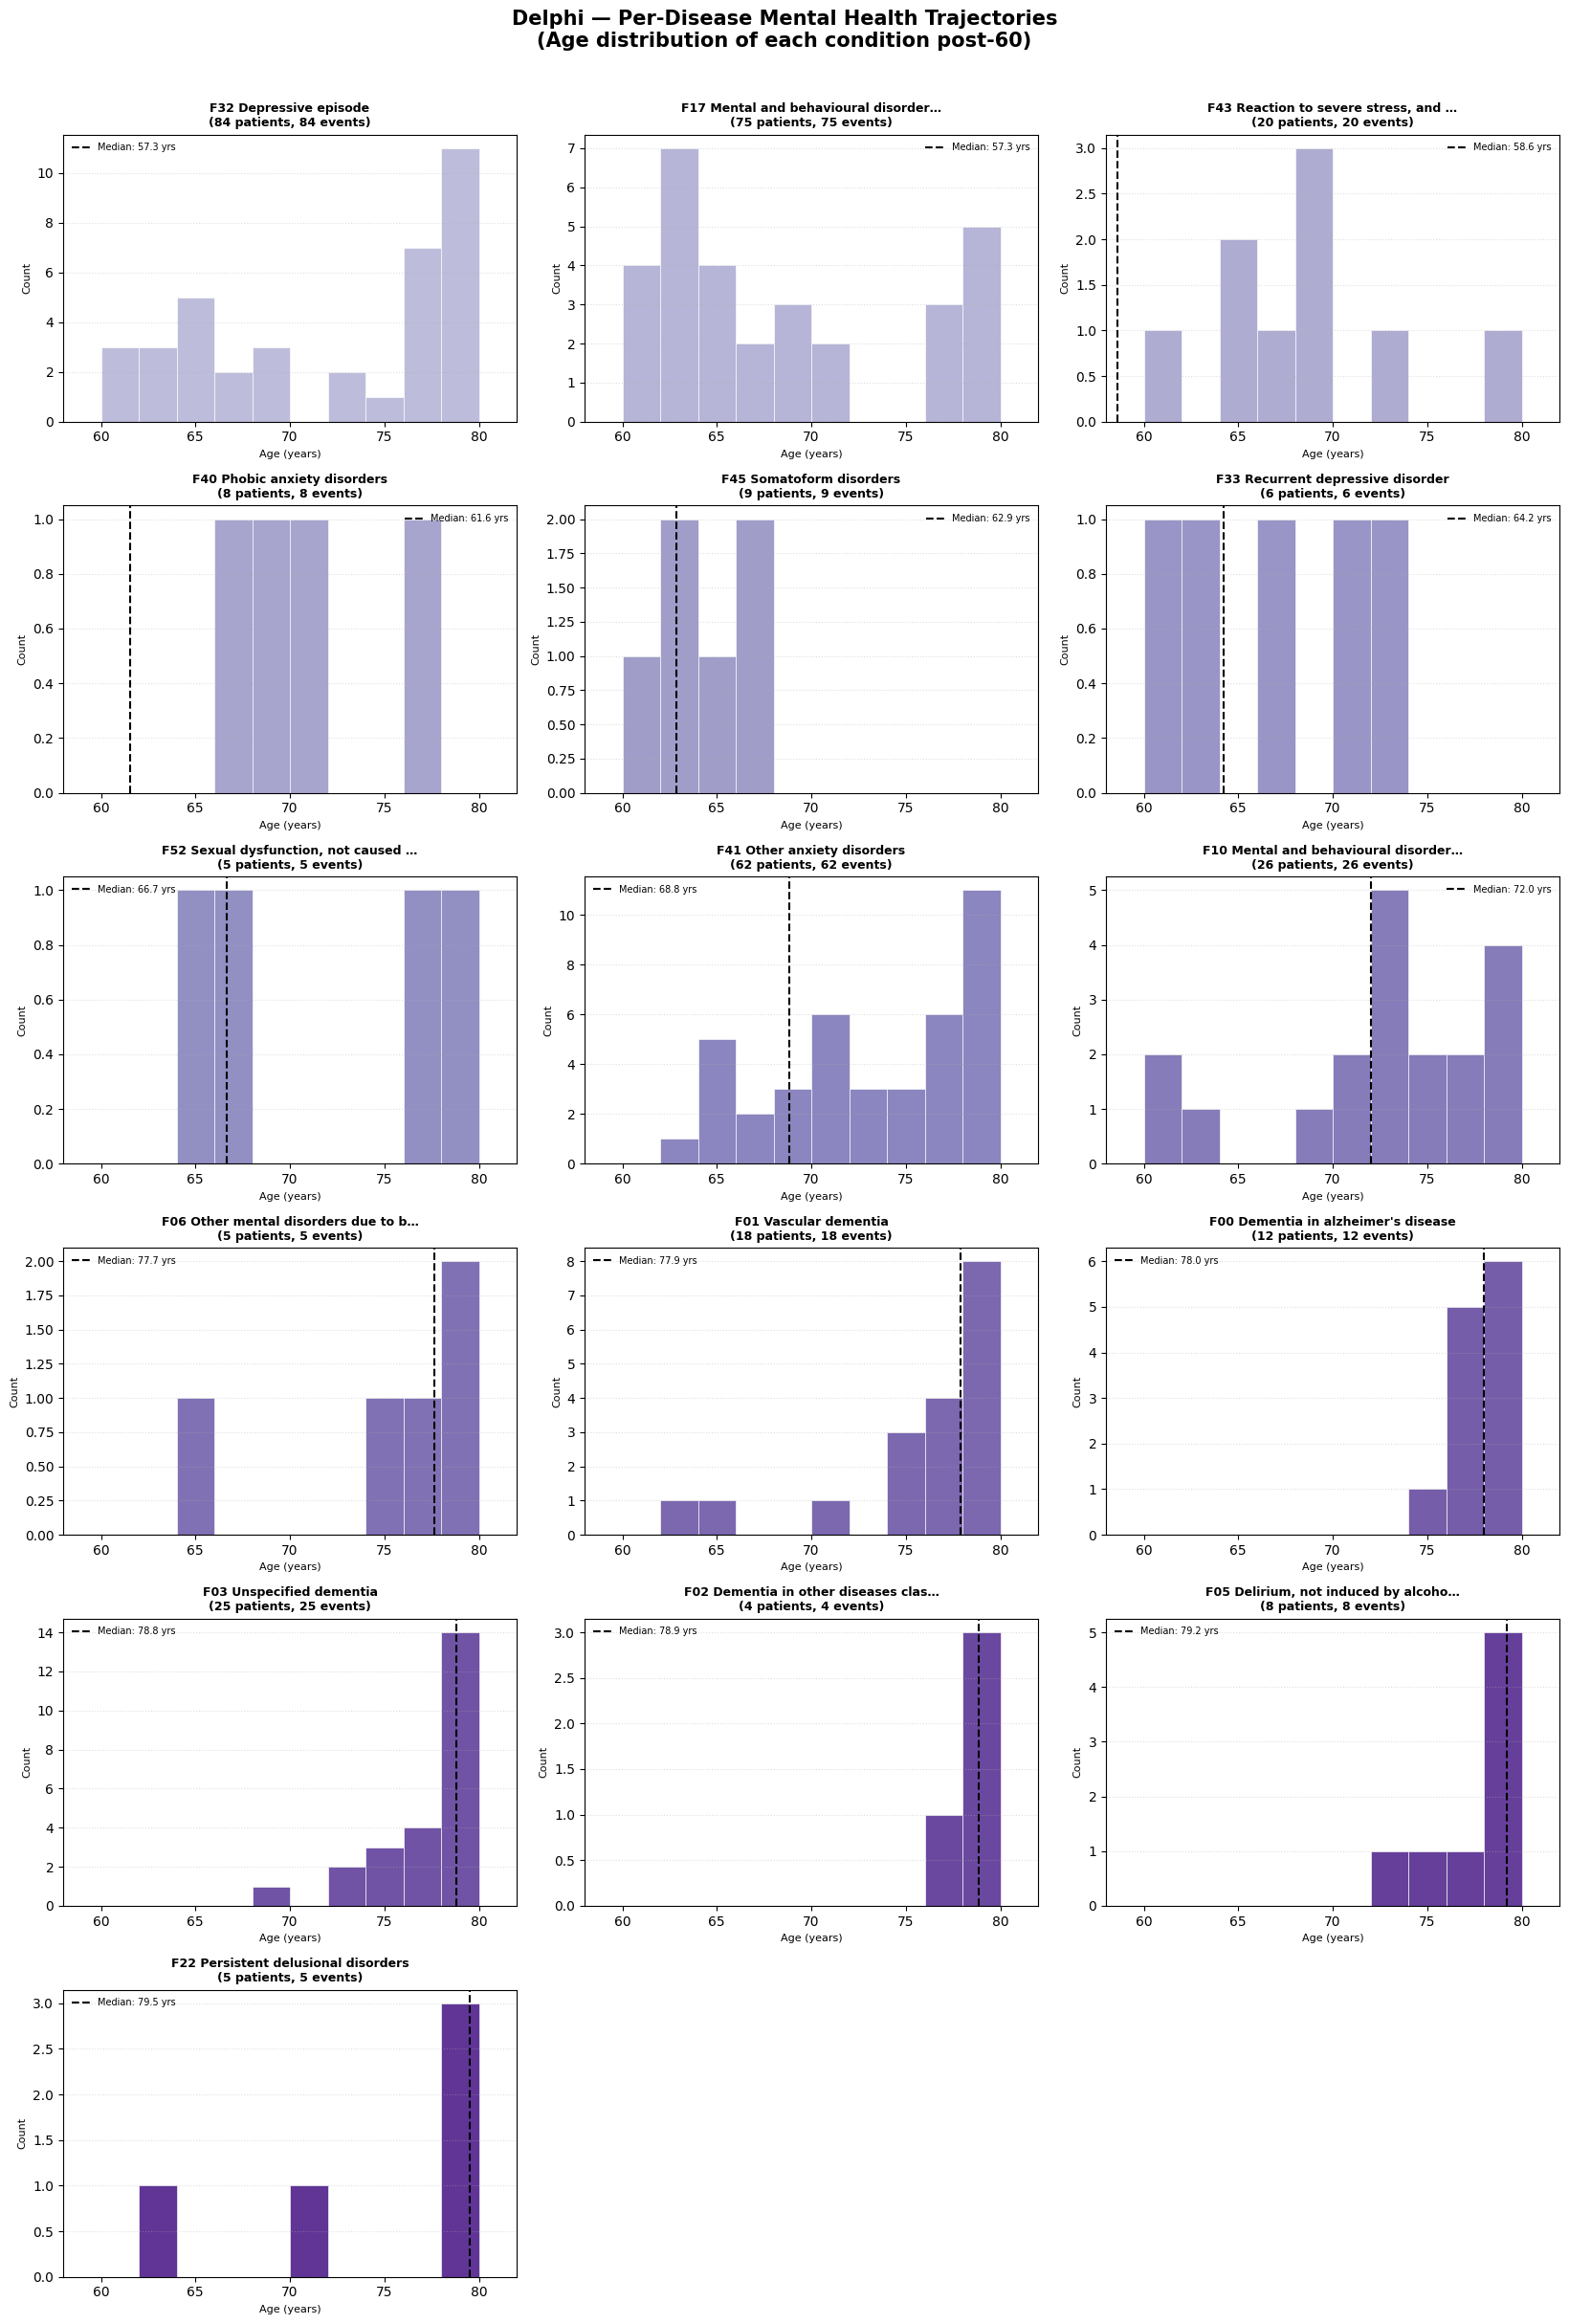

Saved plot3


In [23]:
# ── Cell 9: PLOT 3 — Per-Disease Mental Health Trajectories ───────────────
# This is the key plot your professor asked for
# Shows trajectory pattern for EACH mental health disease separately

# Group all MH events by disease name
mh_by_disease = defaultdict(lambda: {'ages': [], 'patients': set()})
for pid, traj in enumerate(trajectories):
    for age_v, tok in zip(traj['ages'], traj['events']):
        if int(tok) in mh_tokens:
            name, _, _ = token_label(tok)
            short = name[:35] + '…' if len(name) > 35 else name
            mh_by_disease[short]['ages'].append(age_v)
            mh_by_disease[short]['patients'].add(pid)

# Only keep diseases that appeared in at least 3 patients
mh_filtered = {k: v for k, v in mh_by_disease.items() if len(v['patients']) >= 3}
print(f'Mental health diseases with ≥3 patients: {len(mh_filtered)}')
for k, v in sorted(mh_filtered.items(), key=lambda x: -len(x[1]['patients'])):
    print(f'  {k}: {len(v["patients"])} patients, {len(v["ages"])} events')

if mh_filtered:
    diseases_sorted = sorted(mh_filtered.keys(),
                             key=lambda x: np.median(mh_filtered[x]['ages']))
    n_diseases = len(diseases_sorted)
    cols_g = min(3, n_diseases)
    rows_g = (n_diseases + cols_g - 1) // cols_g

    fig, axes = plt.subplots(rows_g, cols_g,
                             figsize=(cols_g * 5.5, rows_g * 4),
                             sharey=False)
    fig.suptitle('Delphi — Per-Disease Mental Health Trajectories\n(Age distribution of each condition post-60)',
                 fontsize=15, fontweight='bold', y=1.01)

    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    purple_shades = plt.cm.Purples(np.linspace(0.4, 0.9, n_diseases))

    for di, disease in enumerate(diseases_sorted):
        ax      = axes_flat[di]
        ages_d  = np.array(mh_filtered[disease]['ages'])
        n_pts   = len(mh_filtered[disease]['patients'])
        color   = purple_shades[di]

        # Histogram of ages when this disease appears
        bins = np.arange(60, 82, 2)
        ax.hist(ages_d, bins=bins, color=color, edgecolor='white',
                linewidth=0.5, alpha=0.9)

        # Median line
        median_age = np.median(ages_d)
        ax.axvline(median_age, color='black', ls='--', lw=1.5,
                   label=f'Median: {median_age:.1f} yrs')

        ax.set_title(f'{disease}\n({n_pts} patients, {len(ages_d)} events)',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Age (years)', fontsize=8)
        ax.set_ylabel('Count', fontsize=8)
        ax.set_xlim(58, 82)
        ax.legend(fontsize=7, frameon=False)
        ax.grid(True, axis='y', linestyle=':', alpha=0.4)

    for di in range(n_diseases, len(axes_flat)):
        axes_flat[di].set_visible(False)

    plt.tight_layout()
    fig.savefig('delphi_plots/plot3_per_disease_trajectories.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved plot3')
else:
    print('Not enough mental health events — try increasing N_PATIENTS')

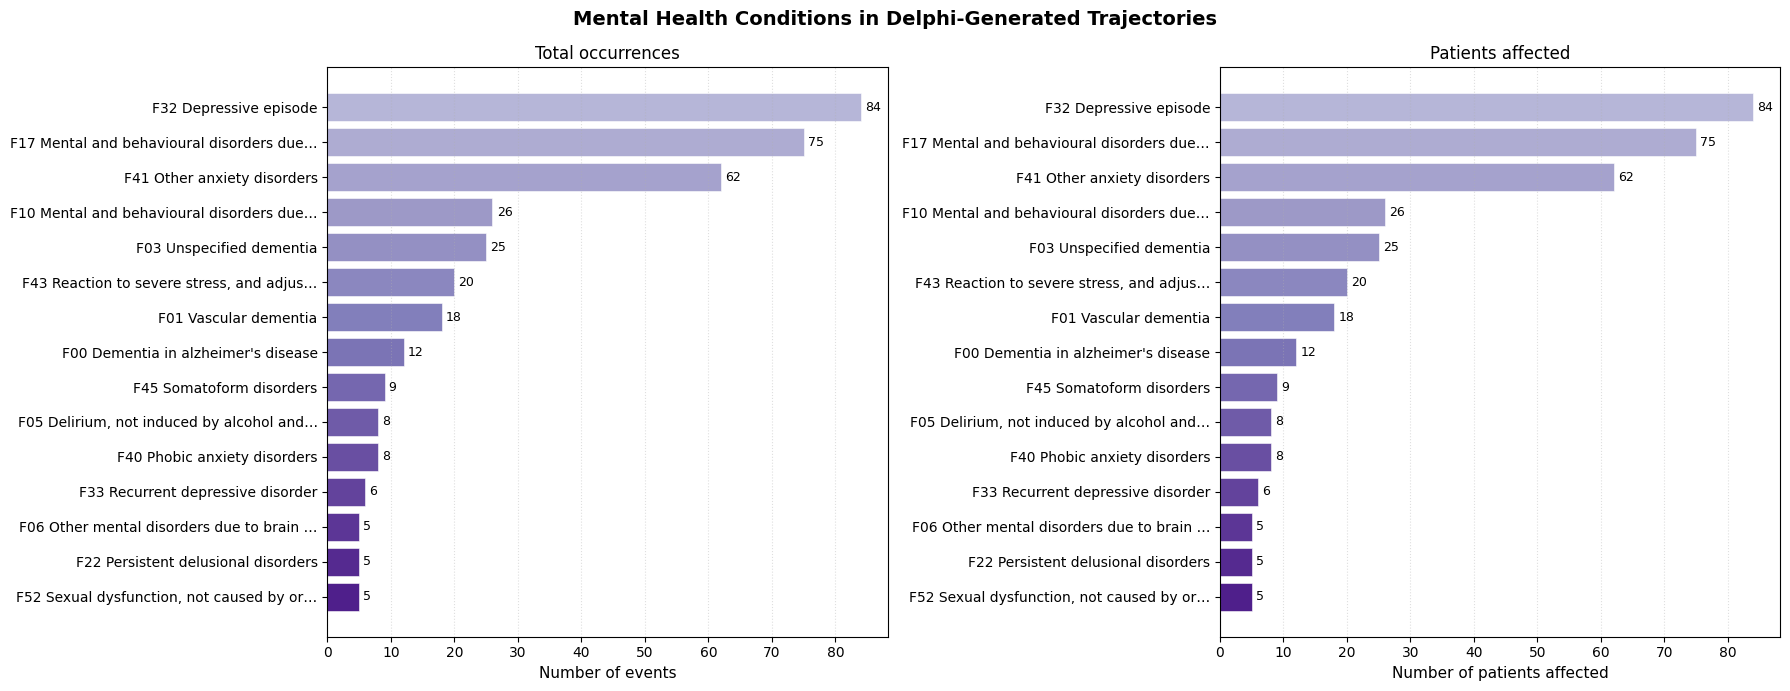

Saved plot4


In [24]:
# ── Cell 10: PLOT 4 — Top Mental Health Conditions Bar Chart ──────────────
mh_name_counts = defaultdict(int)
mh_patient_counts = defaultdict(set)
for pid, traj in enumerate(trajectories):
    for age_v, tok in zip(traj['ages'], traj['events']):
        if int(tok) in mh_tokens:
            name, _, _ = token_label(tok)
            short = name[:40] + '…' if len(name) > 40 else name
            mh_name_counts[short] += 1
            mh_patient_counts[short].add(pid)

if mh_name_counts:
    top_n    = sorted(mh_name_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    labels_  = [x[0] for x in top_n]
    counts_  = [x[1] for x in top_n]
    n_pts_   = [len(mh_patient_counts[l]) for l in labels_]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Mental Health Conditions in Delphi-Generated Trajectories',
                 fontsize=14, fontweight='bold')

    colors_ = plt.cm.Purples(np.linspace(0.4, 0.9, len(labels_)))[::-1]

    # Left: event counts
    bars1 = ax1.barh(labels_[::-1], counts_[::-1], color=colors_, edgecolor='white', lw=0.4)
    ax1.bar_label(bars1, padding=3, fontsize=9)
    ax1.set_xlabel('Number of events', fontsize=11)
    ax1.set_title('Total occurrences', fontsize=12)
    ax1.grid(True, axis='x', linestyle=':', alpha=0.4)

    # Right: patient counts
    bars2 = ax2.barh(labels_[::-1], n_pts_[::-1], color=colors_, edgecolor='white', lw=0.4)
    ax2.bar_label(bars2, padding=3, fontsize=9)
    ax2.set_xlabel('Number of patients affected', fontsize=11)
    ax2.set_title('Patients affected', fontsize=12)
    ax2.grid(True, axis='x', linestyle=':', alpha=0.4)

    plt.tight_layout()
    fig.savefig('delphi_plots/plot4_top_mh_conditions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved plot4')

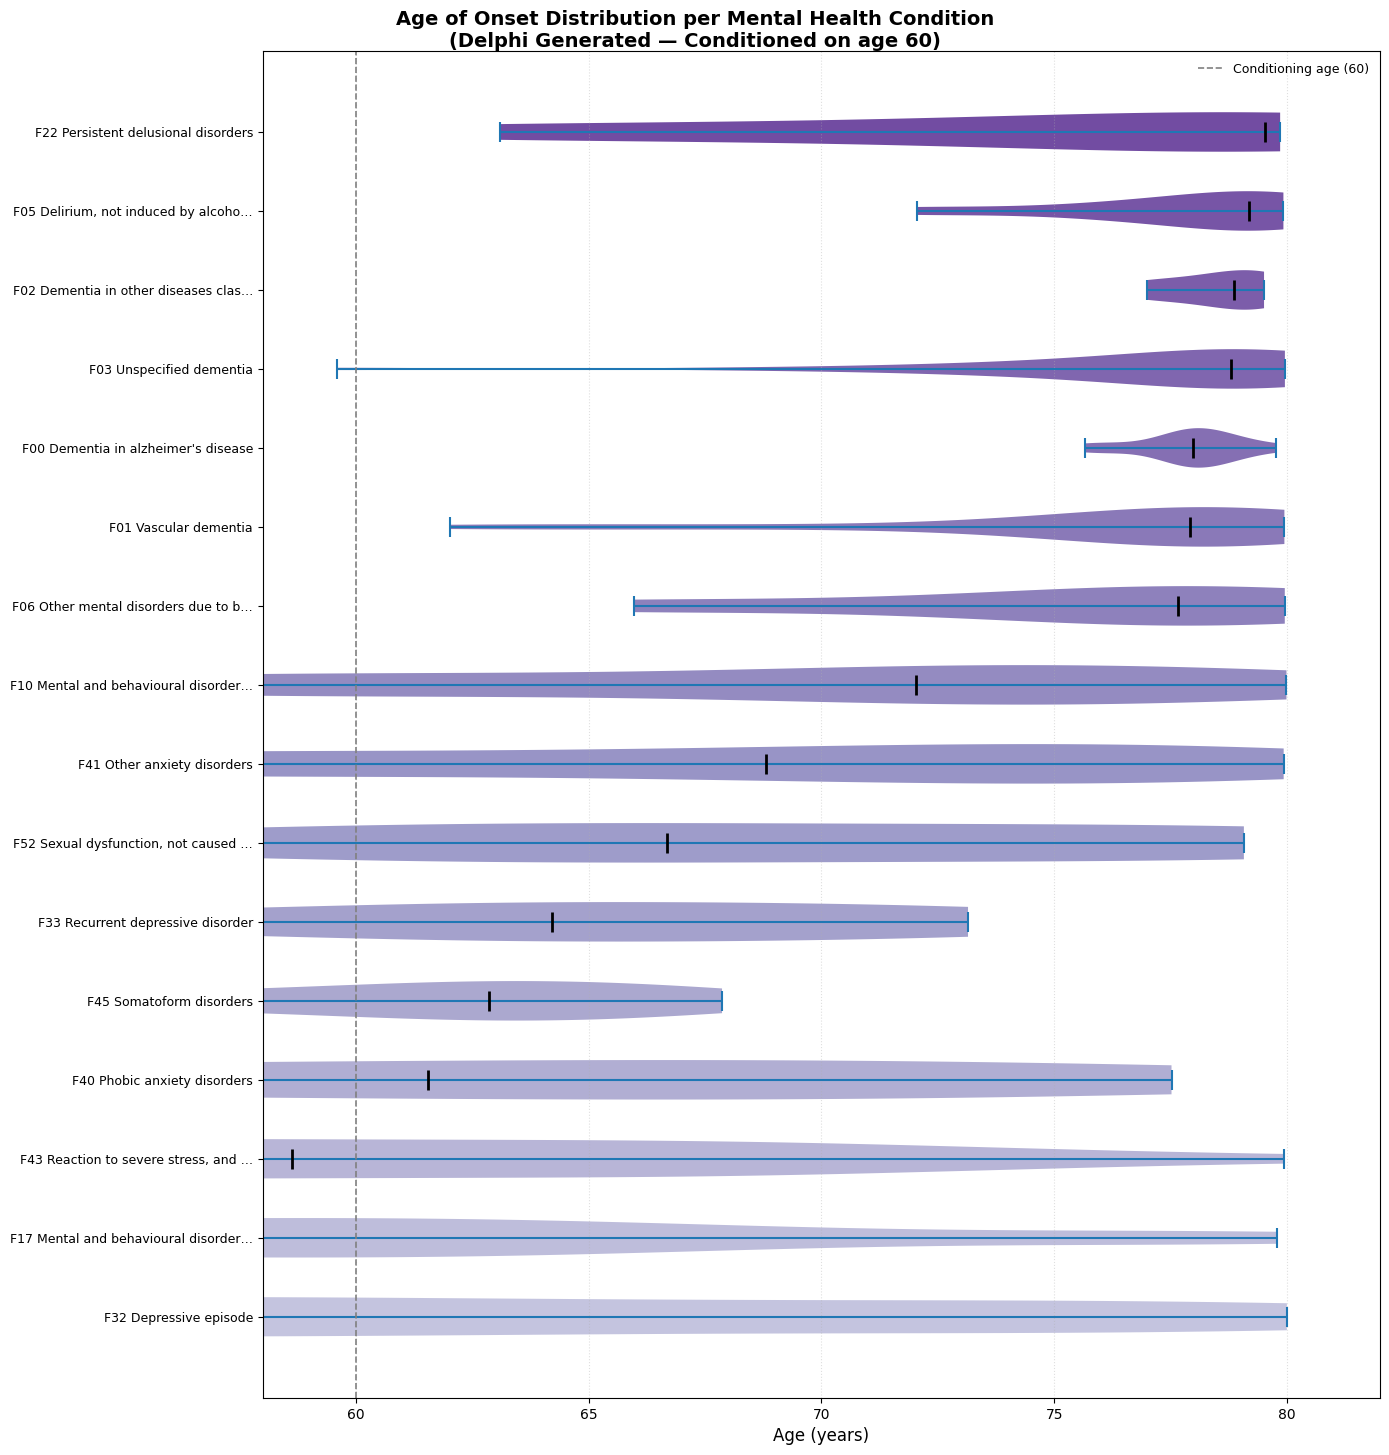

Saved plot5


In [25]:

if mh_filtered:
    diseases_violin = sorted(mh_filtered.keys(),
                             key=lambda x: np.median(mh_filtered[x]['ages']))
    data_list = [mh_filtered[d]['ages'] for d in diseases_violin]

    fig, ax = plt.subplots(figsize=(14, max(6, len(diseases_violin) * 0.8 + 2)))
    fig.suptitle('Age of Onset Distribution per Mental Health Condition\n(Delphi Generated — Conditioned on age 60)',
                 fontsize=14, fontweight='bold')

    parts = ax.violinplot(data_list, vert=False, showmedians=True, showextrema=True)
    for i, body in enumerate(parts['bodies']):
        shade = plt.cm.Purples(0.4 + 0.5 * i / max(len(data_list)-1, 1))
        body.set_facecolor(shade)
        body.set_alpha(0.8)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    ax.set_yticks(range(1, len(diseases_violin)+1))
    ax.set_yticklabels(diseases_violin, fontsize=9)
    ax.set_xlabel('Age (years)', fontsize=12)
    ax.set_xlim(58, 82)
    ax.axvline(60, color='gray', ls='--', lw=1.2, label='Conditioning age (60)')
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    fig.savefig('delphi_plots/plot5_onset_violin.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved plot5')

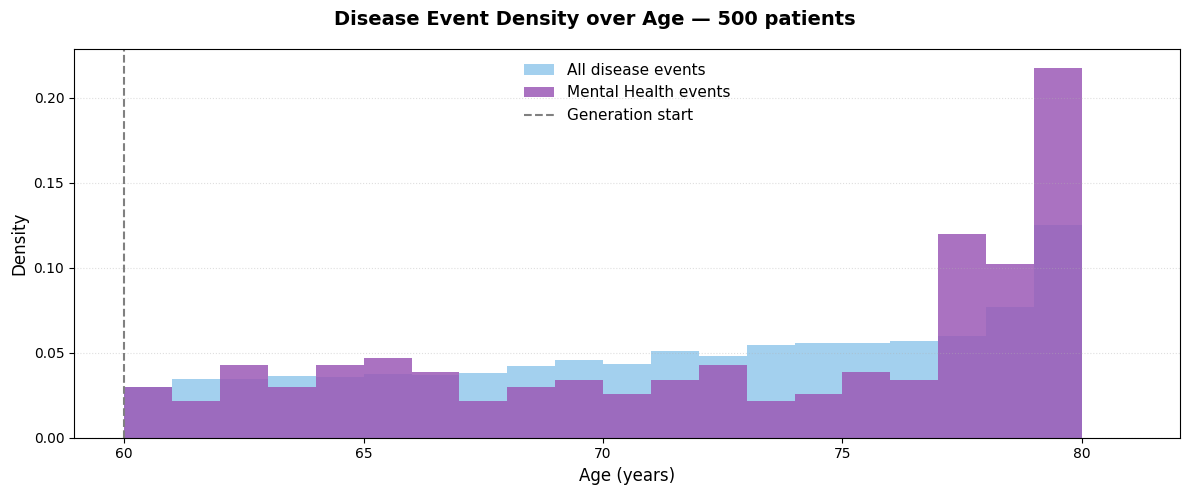

Saved plot6


In [26]:

bins = np.arange(60, 82, 1)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(f'Disease Event Density over Age — {len(trajectories)} patients',
             fontsize=14, fontweight='bold')
ax.hist(all_ages,   bins=bins, alpha=0.45, color='#3498db',
        label='All disease events', density=True)
if len(mh_ages) > 0:
    ax.hist(mh_ages, bins=bins, alpha=0.85, color='#9b59b6',
            label='Mental Health events', density=True)
ax.axvline(60, color='gray', ls='--', lw=1.5, label='Generation start')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11, frameon=False)
ax.grid(True, axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
fig.savefig('delphi_plots/plot6_event_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot6')

In [27]:

import shutil
shutil.make_archive('delphi_plots', 'zip', 'delphi_plots')

from google.colab import files
files.download('delphi_plots.zip')
print('Downloaded delphi_plots.zip — extract it to get all 6 plots.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded delphi_plots.zip — extract it to get all 6 plots.


In [28]:

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'Patients generated      : {len(trajectories)}')
print(f'Total events            : {len(all_events)}')
print(f'Mental health events    : {is_mh.sum()} ({100*is_mh.mean():.1f}%)')
print(f'Unique MH conditions    : {len(mh_by_disease)}')
print(f'MH conditions (≥3 pts)  : {len(mh_filtered)}')
print('=' * 60)
print('Plots saved:')
for i, name in enumerate([
    'Individual trajectories (16 patients)',
    'Population timeline (50 patients)',
    'Per-disease mental health trajectories  ← KEY PLOT',
    'Top MH conditions (events + patients)',
    'Age of onset violin plot',
    'Event density over age',
], 1):
    print(f'  plot{i}: {name}')
print('=' * 60)

SUMMARY
Patients generated      : 500
Total events            : 11175
Mental health events    : 386 (3.5%)
Unique MH conditions    : 28
MH conditions (≥3 pts)  : 16
Plots saved:
  plot1: Individual trajectories (16 patients)
  plot2: Population timeline (50 patients)
  plot3: Per-disease mental health trajectories  ← KEY PLOT
  plot4: Top MH conditions (events + patients)
  plot5: Age of onset violin plot
  plot6: Event density over age
